# 4.5 权重衰减

权重衰减（weight decay）是缓解过拟合的常用正则化方法。它通过惩罚过大的权重，让模型倾向于使用较平滑、较简单的函数。

原教材：[4.5 权重衰减](https://zh.d2l.ai/chapter_multilayer-perceptrons/weight-decay.html)

> 本章代码只使用 PyTorch、Matplotlib 等基础库，不依赖 `d2l`。

## 学习目标

1. 理解 $L_2$ 正则化为何能够限制模型复杂度；
2. 从零实现权重衰减；
3. 掌握优化器参数 `weight_decay`；
4. 理解为什么偏置通常不进行或较少进行权重衰减。

## 4.5.1 从范数到正则化

在线性模型中，原始平均损失为 $L(\mathbf w,b)$。加入 $L_2$ 惩罚后：

$$L_{\text{reg}}(\mathbf w,b)=L(\mathbf w,b)+\frac{\lambda}{2}\lVert\mathbf w\rVert_2^2.$$

$\lambda$ 控制惩罚强度：$\lambda=0$ 表示不正则化；$\lambda$ 越大，越强烈地把权重推向 0。通常只惩罚权重，不惩罚偏置，因为偏置只有少量参数且主要负责整体平移。

In [1]:
from pathlib import Path  # 统一管理本地和 Google Drive 中的图片路径

import matplotlib.pyplot as plt  # 绘制训练损失与测试损失曲线
import torch  # 提供张量、自动微分和随机数工具
from torch import nn  # 提供 Parameter、Linear 和 MSELoss 等组件
from torch.utils.data import DataLoader, TensorDataset  # 将张量数据组织成小批量迭代器

try:  # 尝试判断当前环境是否为 Google Colab
    from google.colab import drive  # 导入 Colab 的云盘挂载工具
    drive.mount('/content/drive')  # 挂载用户的“我的云端硬盘”
    project_root = Path('/content/drive/MyDrive/d2l_learning')  # 指向云盘中的项目根目录
except ImportError:  # 本地环境没有 google.colab 时进入此分支
    project_root = Path.cwd().parent if Path.cwd().name == 'Chapter_4' else Path.cwd()  # 推断本地项目根目录

figure_dir = project_root / 'Chapter_4' / 'images'  # 设置第 4 章图片目录
figure_dir.mkdir(parents=True, exist_ok=True)  # 创建目录且允许目录已经存在
torch.manual_seed(42)  # 固定 CPU 随机种子以复现实验结果
device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))  # 优先选择 CUDA，其次选择 MPS，最后使用 CPU
print('计算设备:', device)  # 输出实际采用的训练设备

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
计算设备: cpu


## 4.5.2 高维小样本实验

我们生成一个 200 维线性回归问题，但只给模型 20 个训练样本。参数很多、样本很少，因此没有正则化时很容易过拟合。真实关系为

$$y=0.05\sum_{i=1}^{200}x_i+0.05+\epsilon.$$

In [2]:
num_inputs, num_train, num_test = 200, 20, 100  # 设置特征数以及训练和测试样本数
batch_size = 5  # 设置每个训练小批量包含 5 个样本
true_w = torch.full((num_inputs, 1), 0.05, device=device)  # 在计算设备上创建元素均为 0.05 的真实权重
true_b = 0.05  # 设置生成数据时使用的真实偏置

def synthetic_data(num_examples):  # 定义生成指定数量线性回归样本的函数
    X = torch.randn(num_examples, num_inputs, device=device)  # 在计算设备上生成标准正态分布的高维输入
    y = X @ true_w + true_b  # 根据真实权重和偏置计算无噪声标签
    y += torch.randn_like(y) * 0.01  # 向标签加入标准差为 0.01 的高斯噪声
    return X, y  # 返回特征矩阵与标签列向量

train_X, train_y = synthetic_data(num_train)  # 生成只有 20 个样本的训练集
test_X, test_y = synthetic_data(num_test)  # 生成独立的 100 个样本测试集
train_iter = DataLoader(TensorDataset(train_X, train_y), batch_size=batch_size, shuffle=True)  # 创建随机打乱的训练迭代器
test_iter = DataLoader(TensorDataset(test_X, test_y), batch_size=batch_size, shuffle=False)  # 创建顺序固定的测试迭代器
print('训练输入形状:', train_X.shape)  # 检查训练输入是否为 [20,200]
print('测试输入形状:', test_X.shape)  # 检查测试输入是否为 [100,200]

训练输入形状: torch.Size([20, 200])
测试输入形状: torch.Size([100, 200])


## 4.5.3 从零实现

下面显式计算 $\frac{1}{2}\sum_i w_i^2$ 并加入数据损失。观察无正则化与有正则化时训练/测试损失和权重范数的区别。

In [3]:
def l2_penalty(w):  # 定义权重向量的 L2 惩罚项
    return torch.sum(w.pow(2)) / 2  # 返回二分之一乘权重平方和

def evaluate_mse(model, data_iter, loss_fn):  # 定义计算整个数据集平均均方误差的函数
    loss_sum, total = 0.0, 0  # 初始化损失总和与样本总数
    with torch.no_grad():  # 评估阶段关闭梯度记录
        for X, y in data_iter:  # 逐批读取特征和标签
            batch_loss = loss_fn(model(X), y)  # 计算当前批次的平均均方误差
            loss_sum += batch_loss.item() * y.numel()  # 将批平均损失转换为损失总和后累计
            total += y.numel()  # 累加当前批次的标签数
    return loss_sum / total  # 返回整个数据集每个样本的平均损失

def train_scratch(lambd, num_epochs=100, learning_rate=0.003):  # 定义从零训练并指定正则化强度的函数
    w = nn.Parameter(torch.randn(num_inputs, 1, device=device) * 0.01)  # 在计算设备上创建可训练权重 [200,1]
    b = nn.Parameter(torch.zeros(1, device=device))  # 在计算设备上创建可训练偏置 [1]
    model = lambda X: X @ w + b  # 使用矩阵乘法和广播定义线性模型
    loss_fn = nn.MSELoss()  # 创建返回批平均值的均方误差损失
    optimizer = torch.optim.SGD([w, b], lr=learning_rate)  # 创建更新手动参数的 SGD 优化器
    history = {'train': [], 'test': []}  # 创建保存每轮训练和测试损失的字典
    for epoch in range(num_epochs):  # 重复遍历训练集指定轮数
        for X, y in train_iter:  # 逐个小批量训练模型
            optimizer.zero_grad()  # 清除上一批次累积的梯度
            data_loss = loss_fn(model(X), y)  # 计算当前批次的数据拟合损失
            regularized_loss = data_loss + lambd * l2_penalty(w)  # 将 L2 惩罚加入目标函数且不惩罚偏置
            regularized_loss.backward()  # 反向传播计算数据项和正则项的总梯度
            optimizer.step()  # 根据总梯度更新权重和偏置
        history['train'].append(evaluate_mse(model, train_iter, loss_fn))  # 记录不含正则项的训练均方误差
        history['test'].append(evaluate_mse(model, test_iter, loss_fn))  # 记录独立测试集均方误差
    return w.detach(), history  # 返回脱离计算图的权重及损失历史

scratch_results = {}  # 创建保存不同正则化强度实验结果的字典
for lambd in [0.0, 3.0]:  # 分别训练无正则化和有正则化的模型
    scratch_results[lambd] = train_scratch(lambd)  # 保存当前正则化强度的权重与历史
    learned_w, history = scratch_results[lambd]  # 取出当前实验结果
    print(f'lambda={lambd:.1f}: 测试损失={history["test"][-1]:.6f}, ||w||={learned_w.norm():.4f}')  # 输出泛化误差和权重范数

lambda=0.0: 测试损失=0.472107, ||w||=0.2636
lambda=3.0: 测试损失=0.424036, ||w||=0.1973


图片已保存到：/content/drive/MyDrive/d2l_learning/Chapter_4/images/4.5_weight_decay.png


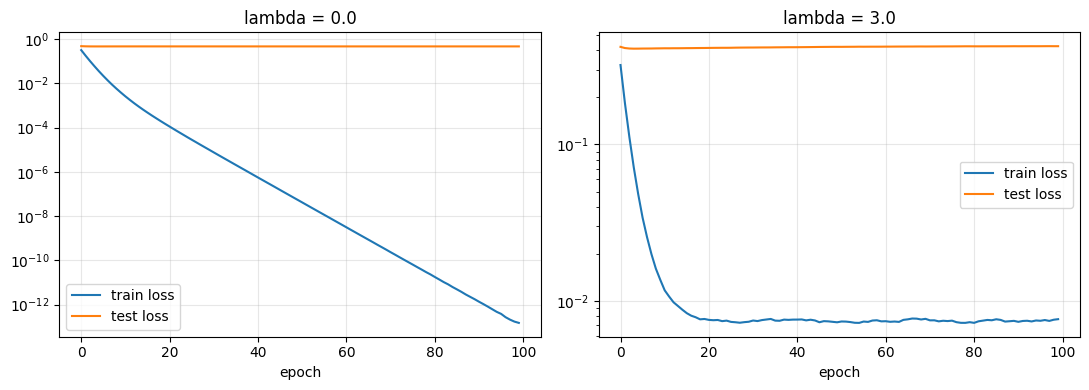

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))  # 创建两个正则化实验的并排画布
for axis, lambd in zip(axes, [0.0, 3.0]):  # 逐个选择坐标轴和正则化强度
    history = scratch_results[lambd][1]  # 取出当前实验的损失历史
    axis.semilogy(history['train'], label='train loss')  # 用对数纵轴绘制训练损失
    axis.semilogy(history['test'], label='test loss')  # 用对数纵轴绘制测试损失
    axis.set_title(f'lambda = {lambd}')  # 设置当前正则化强度标题
    axis.set_xlabel('epoch')  # 设置横轴为训练轮次
    axis.grid(alpha=0.3)  # 添加半透明网格辅助读数
    axis.legend()  # 显示训练损失与测试损失图例
plt.tight_layout()  # 自动调整子图间距
figure_path = figure_dir / '4.5_weight_decay.png'  # 生成图片的完整保存路径
fig.savefig(figure_path, dpi=160, bbox_inches='tight')  # 保存高清图片并裁掉多余白边
print(f'图片已保存到：{figure_path}')  # 输出图片保存位置
plt.show()  # 在 Notebook 中显示损失曲线

## 4.5.4 简洁实现

PyTorch 优化器的 `weight_decay` 参数可以直接实现权重衰减。为了不衰减偏置，将权重和偏置放入两个参数组。

In [5]:
def train_concise(weight_decay, num_epochs=100, learning_rate=0.003):  # 定义使用优化器内置权重衰减的训练函数
    model = nn.Linear(num_inputs, 1).to(device)  # 创建线性层并将参数移动到计算设备
    nn.init.normal_(model.weight, mean=0.0, std=0.01)  # 使用小随机数初始化权重
    nn.init.zeros_(model.bias)  # 将偏置初始化为 0
    loss_fn = nn.MSELoss()  # 创建均方误差损失函数
    optimizer = torch.optim.SGD([  # 创建包含两个参数组的 SGD 优化器
        {'params': model.weight, 'weight_decay': weight_decay},  # 只对权重应用指定强度的衰减
        {'params': model.bias, 'weight_decay': 0.0},  # 不对偏置应用权重衰减
    ], lr=learning_rate)  # 为两个参数组设置共同学习率
    for epoch in range(num_epochs):  # 重复遍历训练集指定轮数
        for X, y in train_iter:  # 逐个小批量读取训练数据
            optimizer.zero_grad()  # 清除上一批次累积在参数上的梯度
            loss = loss_fn(model(X), y)  # 前向传播并计算数据拟合损失
            loss.backward()  # 反向传播计算数据损失的梯度
            optimizer.step()  # 更新参数并自动对权重执行衰减
    test_loss = evaluate_mse(model, test_iter, loss_fn)  # 计算训练完成后的测试均方误差
    return model, test_loss  # 返回训练完成的模型及测试损失

concise_model, concise_test_loss = train_concise(weight_decay=3.0)  # 使用内置权重衰减训练模型
print('简洁实现测试损失:', concise_test_loss)  # 输出简洁实现的测试损失
print('简洁实现权重范数:', concise_model.weight.detach().norm().item())  # 输出最终权重的 L2 范数

简洁实现测试损失: 0.42524211909621956
简洁实现权重范数: 0.19786956906318665


## 4.5.5 小结

- 权重衰减通过限制权重的 $L_2$ 范数降低模型有效复杂度；
- $\lambda$ 越大，权重通常越接近 0，但过大也会造成欠拟合；
- 从零实现是在损失中显式加入惩罚项；
- 简洁实现使用优化器的 `weight_decay`，并可用参数组区别对待权重与偏置。

## 4.5.6 练习与参考答案

1. **若 $\lambda$ 过大会怎样？** 权重被过度压缩，模型容量不足，训练误差和测试误差都可能升高。
2. **为什么通常不衰减偏置？** 偏置参数很少，主要控制输出平移，对复杂度的贡献通常小于权重。
3. **`weight_decay=0` 表示什么？** 表示关闭权重衰减，优化器只根据原始数据损失更新参数。
4. **权重衰减能否保证不发生过拟合？** 不能。它只是调节模型复杂度的工具，还需结合验证集、数据量和其他正则化方法选择强度。